In [1]:
import warnings
import inspect
from copy import deepcopy
warnings.filterwarnings("ignore")
import logging
from statkit.decision import NetBenefitDisplay
import scipy
from sklearn.metrics import * 
import pandas as pd
import seaborn as sns
import numpy as np
import shap
import torch
import os
import inspect 
import torch.nn as nn
import matplotlib.pyplot as plt
import pickle
from numpy import sqrt
from numpy import argmax
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve
from matplotlib import pyplot
from torchinfo import summary as torchsummary
from torchvision import models, transforms
from model import init_model, init_transforms
from dataset import init_dataloader
from matplotlib import pyplot
from pathlib import Path
import inspect
sns.set(rc={'figure.figsize':(11.7,8.27)})
pd.options.display.max_rows = 999
pd.options.display.max_columns = 999




In [2]:
ROOT_DIR = Path(os.path.dirname(os.path.abspath('')))
TOTAL_TRAIN_SAMPLES = 50
TOTAL_TEST_SAMPLES = 10
CHANNELS = 3
DEVICE = "cuda:1"
OCT_PRESENCE = "Usando OCT"
DUAL_IMAGE = "Dual Image"
DATA_PATH = "../data.csv"
SUMMARY_PATH = "../model_summary.csv"
HISTORY_PATH = "../history.csv"
FT_SIZE = 24
ARQ1 = "SI"
ARQ2 = "SIT"
ARQ3 = "DI"
ARQ4 = "DIT"

In [3]:
def get_samples_from_loader(loader, size):
    """
    Return photos1, photos2, ft_numerical, labels
    """

    list_of_photos_1 = []
    list_of_photos_2 = []
    list_of_features = []
    list_of_labels = []

    for photos1, photos2, numericalft, labels in loader:
        for i in range(len(labels)):
            list_of_photos_1.append(photos1[i])
            list_of_photos_2.append(photos2[i])
            list_of_features.append(numericalft[i])
            list_of_labels.append(labels[i].numpy())

            if len(list_of_labels) >= size:
                break

        if len(list_of_labels) >= size:
            break

    photos1 = torch.stack(list_of_photos_1)
    photos2 = torch.stack(list_of_photos_2)
    ft_numerical = torch.stack(list_of_features)
    labels = np.array(list_of_labels)

    return (photos1, photos2, ft_numerical, labels)


In [4]:
def get_samples_from_loader_balanced(loader, size):
    """
    Return photos1, photos2, ft_numerical, labels
    """

    list_of_photos_1 = []
    list_of_photos_2 = []
    list_of_features = []
    list_of_labels = []

    positive_class = 0
    negative_class = 0

    for photos1, photos2, numericalft, labels in loader:
        for i in range(len(labels)):
            if int(labels[i].numpy()) == 0 and negative_class >= (size / 2):
                continue
            elif int(labels[i].numpy()) == 0 and negative_class < (size / 2):
                negative_class += 1

            if int(labels[i].numpy()) == 1 and positive_class >= (size / 2):
                continue
            elif int(labels[i].numpy()) == 1 and positive_class < (size / 2):
                positive_class += 1

            list_of_photos_1.append(photos1[i])
            list_of_photos_2.append(photos2[i])
            list_of_features.append(numericalft[i])
            list_of_labels.append(labels[i].numpy())

        if len(list_of_labels) >= size:
            break

    photos1 = torch.stack(list_of_photos_1)
    photos2 = torch.stack(list_of_photos_2)
    ft_numerical = torch.stack(list_of_features)
    labels = np.array(list_of_labels)

    return (photos1, photos2, ft_numerical, labels)


In [5]:
def load_model_and_loaders(model_row, model_id):
    """
        Return model, train_loader, val_loader
    """ 
    model_name = model_row["backbone"].values[0]
    pretrained = False
    feature_extract = False
    double_img_bool = False
    output_tab = 5 
    model, input_size = init_model(model_name,pretrained, double_img_bool, output_tab, FT_SIZE)
    model.load_state_dict(torch.load("../models/" + str(model_id) + "/" + "model"+ "_fold_1.pth"))
    train_loader = torch.load("../models/" + str(model_id) + "/train_dataloader" + "_fold_1.pth")
    val_loader = torch.load("../models/" + str(model_id) + "/val_dataloader" + "_fold_1.pth")
    
    val_loader.dataset.root_dir = ROOT_DIR
    train_loader.dataset.root_dir = ROOT_DIR
    
    return model, train_loader, val_loader, input_size

In [6]:
def create_explainers(model, device, photos1_train, photos2_train, ft_numerical_train, 
                                     photos1_val, photos2_val, ft_numerical_val, input_size):
    """
        Return shap_values_photo1, shap_values_photo2, shap_values_nuermical
    """ 
    
    model = model.to(device)
    explainer = shap.DeepExplainer(model, [photos1_train.to(device),photos2_train.to(device),ft_numerical_train.to(device)])
    shap_values_photo1, shap_values_photo2, shap_values_numerical = explainer.shap_values([photos1_val.to(device),photos2_val.to(device), ft_numerical_val.to(device)])
    
    photos1_list = []
    photos2_list = []
    for i in range(len(photos1_val)):
        photos1_list.append(imshow(photos1_val[i]))
        photos2_list.append(imshow(photos2_val[i]))
        
    
    photos1_numpy = np.asarray(photos1_list)
    photos2_numpy = np.asarray(photos2_list)
    
    return (shap_values_photo1.reshape(-1, input_size, input_size, CHANNELS), 
            shap_values_photo2.reshape(-1, input_size, input_size, CHANNELS), 
            shap_values_numerical,
            photos1_numpy, 
            photos2_numpy)

In [7]:
def plot_image(shap_values, photos, total):
    
    return shap.image_plot(shap_values[:total], photos[:total])

In [8]:
def imshow(image):
    npimg = image.numpy()
    npimg = np.transpose(npimg, (1,2,0))
    npimg = ((npimg * [0.229, 0.224, 0.225]) + [0.485, 0.456, 0.406])
    return npimg

In [9]:
def shapley_feature_ranking(shap_values):
    feature_order = np.argsort(np.mean(np.abs(shap_values), axis=0))
    return pd.DataFrame(
        {
            "features": [numerical_columns[i] for i in feature_order][::-1],
            "importance": [
                np.mean(np.abs(shap_values), axis=0)[i] for i in feature_order
            ][::-1],
        }
    )

In [10]:
def get_rank_per_group(df_max,df_avg):
    dict_rows = {}
    dict_rows["Backbone"] = []
    dict_rows[OCT_PRESENCE] = []
    dict_rows[DUAL_IMAGE] = []
    dict_rows["Max Auc Rank"] = []
    dict_rows["Avg Auc Rank"] = []
 
 
    df_max = df_max.sort_values(by=["backbone",OCT_PRESENCE,DUAL_IMAGE])
    df_avg = df_avg.sort_values(by=["backbone",OCT_PRESENCE,DUAL_IMAGE])
    
    
    for index, row in df_max.iterrows():
        dict_rows["Backbone"].append(row["backbone"])
        dict_rows[OCT_PRESENCE].append(row[OCT_PRESENCE])
        dict_rows[DUAL_IMAGE].append(row[DUAL_IMAGE])
        dict_rows["Max Auc Rank"].append(row["rank_max_auc_oct_double"])
        
    for index, row in df_avg.iterrows():
        dict_rows["Avg Auc Rank"].append(row["rank_avg_auc_oct_double"])
        
    df_rank_per_group = pd.DataFrame.from_dict(dict_rows)
    return df_rank_per_group

In [11]:
def get_numpy(val_loader):
    photos1_val, photos2_val, ft_numerical_val, labels_val =  get_samples_from_loader(val_loader, len(val_loader.dataset))
    photos1_list = []
    photos2_list = []
    photos1_list_non_inv = []
    photos2_list_non_inv = []
    ft_numerical_list = []
    labels_list = []
    for i in range(len(photos1_val)):
        photos1_list.append(imshow(photos1_val[i]))
        photos2_list.append(imshow(photos2_val[i]))
        photos1_list_non_inv.append(deepcopy(photos1_val[i]))
        photos2_list_non_inv.append(deepcopy(photos2_val[i]))
        ft_numerical_list.append(ft_numerical_val[i].numpy())
        labels_list.append(labels_val[i])


    photos1_numpy = np.asarray(photos1_list)
    photos2_numpy = np.asarray(photos2_list)
    photos1_numpy_non_inv = np.asarray(photos1_list_non_inv)
    photos2_numpy_non_inv = np.asarray(photos2_list_non_inv)
    ft_numerical_numpy = np.asarray(ft_numerical_list)
    return photos1_numpy, photos2_numpy, photos1_numpy_non_inv, photos2_numpy_non_inv, ft_numerical_numpy, labels_list

In [147]:
data = pd.read_csv(DATA_PATH)
summary = pd.read_csv(SUMMARY_PATH)
filter_summary = pd.read_csv("../filter_top1.csv")
df_peak = pd.read_csv("../df_peak_mem_summary.csv")
history = pd.read_csv(HISTORY_PATH)
os.environ["NUM_WORKERS"] = "8"
device = "cuda"
important_columns = ['model_id', 'k_fold', 'frac_val', 'val_best_acc', 'val_best_auc','host_name', 'optim', 'lr', 'scheduler',
       'randaugop', 'epochs', 'double_img', 'output_tab', 'backbone',
       'early_start', 'patient_el','oos_best_auc',
       'avg_best_auc_oos','std_val_auc', 'std_oos_auc',
       'inference_time', 'avg_best_auc_val', 'max_sp_oos', 'max_sn_oos',
       'idx_max_sp_val', 'idx_max_sn_val', 'idx_avg_sp_val', 'idx_avg_sn_val',
       'avg_sp_oos', 'avg_sn_oos', 'std_sn_oos', 'std_sp_oos',
       'idx_std_sn_val', 'idx_std_sp_val']


In [148]:
model_id = "b674627d958947d79102841cdd7e2d90" 


In [149]:
row = summary[summary["model_id"] == model_id]
model, train_loader, val_loader, input_size =  load_model_and_loaders(row, model_id)
model = model.to(device)

In [150]:
row.squeeze()

model_id                   b674627d958947d79102841cdd7e2d90
k_fold                                                  5.0
frac_val                                                NaN
val_best_acc                                       0.986755
val_best_auc                                       0.990654
val_best_sp                                             1.0
val_best_sn                                             1.0
val_avg_acc                                          0.9134
val_avg_auc                                        0.873079
val_avg_sp                                          0.96875
val_avg_sn                                         0.777408
train_best_acc                                     0.963756
train_best_auc                                      0.94411
train_best_sp                                           1.0
train_best_sn                                      0.908537
train_avg_acc                                      0.926337
train_avg_auc                           

In [151]:
train = train_loader.dataset.glaucoma_data
val = val_loader.dataset.glaucoma_data
os.environ["NUM_WORKERS"] = "8"
numerical_columns = train.select_dtypes(include=np.number).columns.tolist()
numerical_columns.remove("label")
ft_size = len(numerical_columns)

In [152]:
val

,Patient,label,photo_1,photo_2,eye_side,gender,G,T,TS,NS,N,NI,TI,age,T/TS,T/NS,T/N,T/NI,T/TI,TS/NS,TS/N,TS/NI,TS/TI,NS/N,NS/NI,NS/TI,N/NI,N/TI,NI/TI
5,ADAO MOREIRA SOUZA 01025453,0,imgs/ADAO MOREIRA SOUZA 01025453/111111_Color_...,imgs/ADAO MOREIRA SOUZA 01025453/111111_Color_...,right,1.0,0.689655,0.458716,0.716763,0.600000,0.685039,0.644578,0.502370,0.580645,0.140835,0.121120,0.090026,0.139436,0.145825,0.328346,0.254294,0.283591,0.147229,0.215417,0.275584,0.198655,0.459761,0.170609,0.137828
6,ADAO MOREIRA SOUZA 01025453,0,imgs/ADAO MOREIRA SOUZA 01025453/111111_Color_...,imgs/ADAO MOREIRA SOUZA 01025453/111111_Color_...,left,1.0,0.706897,0.422018,0.676301,0.491429,0.763780,0.753012,0.521327,0.580645,0.137214,0.147940,0.067904,0.084461,0.120289,0.388637,0.209492,0.227191,0.129266,0.107482,0.188227,0.153938,0.444494,0.186091,0.157057
11,ADELINA MARIA SOUZA BORGES 00575950,0,imgs/ADELINA MARIA SOUZA BORGES 00575950/11111...,imgs/ADELINA MARIA SOUZA BORGES 00575950/11111...,right,0.0,0.577586,0.449541,0.554913,0.577143,0.401575,0.542169,0.592417,0.903226,0.201394,0.125517,0.177418,0.181647,0.102840,0.261328,0.356489,0.261663,0.077942,0.460695,0.311623,0.159729,0.302171,0.068282,0.090610
12,ADELINA MARIA SOUZA BORGES 00575950,0,imgs/ADELINA MARIA SOUZA BORGES 00575950/11111...,imgs/ADELINA MARIA SOUZA BORGES 00575950/11111...,left,0.0,0.551724,0.366972,0.554913,0.651429,0.346457,0.566265,0.554502,0.903226,0.154919,0.077015,0.173695,0.123223,0.083126,0.223383,0.413654,0.250588,0.088006,0.642130,0.340130,0.195773,0.243951,0.060560,0.104651
15,AIDE APARECIDA GONZAGA AMBROSIO 10875110,0,imgs/AIDE APARECIDA GONZAGA AMBROSIO 10875110/...,imgs/AIDE APARECIDA GONZAGA AMBROSIO 10875110/...,right,0.0,0.655172,0.532110,0.618497,0.537143,0.543307,0.584337,0.606635,0.548387,0.215529,0.170692,0.146268,0.205872,0.129717,0.320058,0.285672,0.270110,0.088866,0.267567,0.269059,0.143594,0.392231,0.101270,0.096213
16,AIDE APARECIDA GONZAGA AMBROSIO 10875110,0,imgs/AIDE APARECIDA GONZAGA AMBROSIO 10875110/...,imgs/AIDE APARECIDA GONZAGA AMBROSIO 10875110/...,left,0.0,0.663793,0.440367,0.658960,0.794286,0.503937,0.608434,0.511848,0.548387,0.152337,0.067859,0.132044,0.145054,0.132853,0.208371,0.330231,0.276239,0.128225,0.527310,0.392380,0.262477,0.346515,0.114440,0.126166
44,ANA MARIA MERENCIANO,0,imgs/ANA MARIA MERENCIANO/111111_Color_11MP_R_...,imgs/ANA MARIA MERENCIANO/111111_Color_11MP_R_...,right,0.0,0.482759,0.321101,0.364162,0.354286,0.535433,0.548193,0.473934,0.698925,0.229879,0.172285,0.086935,0.104792,0.094661,0.306517,0.172598,0.172549,0.060377,0.122130,0.182719,0.119496,0.410700,0.135628,0.123309
45,ANA MARIA MERENCIANO,0,imgs/ANA MARIA MERENCIANO/111111_Color_11MP_L_...,imgs/ANA MARIA MERENCIANO/111111_Color_11MP_L_...,left,0.0,0.413793,0.440367,0.410405,0.291429,0.330709,0.349398,0.454976,0.698925,0.283148,0.292486,0.215490,0.313925,0.162703,0.419921,0.331837,0.297199,0.079173,0.224827,0.228315,0.100931,0.371429,0.076513,0.077477
48,ANA PAULA BRITO SOUZA,0,imgs/ANA PAULA BRITO SOUZA/111111_Color_11MP_R...,imgs/ANA PAULA BRITO SOUZA/111111_Color_11MP_R...,right,0.0,0.775862,0.550459,0.687861,0.600000,0.590551,1.072289,0.587678,0.225806,0.194428,0.152066,0.136379,0.056779,0.144931,0.314134,0.289258,0.152826,0.110127,0.279620,0.159108,0.168200,0.220915,0.117797,0.203102
49,ANA PAULA BRITO SOUZA,0,imgs/ANA PAULA BRITO SOUZA/111111_Color_11MP_L...,imgs/ANA PAULA BRITO SOUZA/111111_Color_11MP_L...,left,0.0,0.715517,0.366972,0.641618,0.822857,0.661417,0.819277,0.440758,0.225806,0.121957,0.044049,0.072581,0.043356,0.133604,0.191844,0.236149,0.195643,0.152888,0.383244,0.306484,0.315015,0.345953,0.189181,0.207731


In [153]:
transform_train ,transform_val,_ = init_transforms(224, 0)
train_loader = init_dataloader(train, transform_train, None, 16, numerical_columns, True, False)
val_loader = init_dataloader(val, transform_val, None, 16, numerical_columns, True, False)

In [154]:
(
photos1_train,
photos2_train,
ft_numerical_train,
_,
) = get_samples_from_loader_balanced(train_loader, 50)

In [155]:
(
    photos1_val,
    photos2_val,
    ft_numerical_val,
    _,
) = get_samples_from_loader(val_loader, len(val_loader.dataset))


In [156]:
val_loader.dataset.double_img

True

In [157]:
explainer = shap.DeepExplainer(
    model,
    [
        photos1_train.to(device),
        photos2_train.to(device),
        ft_numerical_train.to(device),
    ],
)


In [158]:
(
    shap_values_photo1,
    shap_values_photo2,
    shap_values_numerical,
) = explainer.shap_values([photos1_val, photos2_val, ft_numerical_val])


In [159]:
df = val_loader.dataset.glaucoma_data


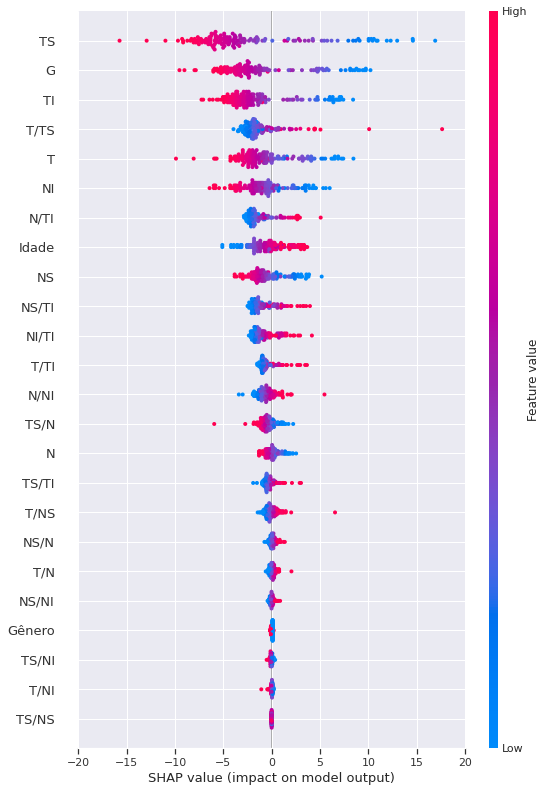

In [160]:
#["TS","G","TI","T/TS","T","NI","N/TI","age","NS","NS/TI","NI/TI","T/TI","N/NI","TS/N","N","TS/TI","T/NS","NS/N","T/N","NS/NI","gender","TS/NI","T/NI","TS/NS"]
plt.xlim(xmin=-20,xmax=20) 
df.rename(columns={"age": "Idade","gender": "Gênero"}, inplace=True)
shap.summary_plot(shap_values_numerical, ft_numerical_val, feature_names=df.iloc[:,5:].columns.values,max_display=30,layered_violin_max_num_bins=40, show=False)

In [161]:
(
    shap_values_photo1,
    shap_values_photo2,
    shap_values_numerical,
) = explainer.shap_values([photos1_train, photos2_train, ft_numerical_train])


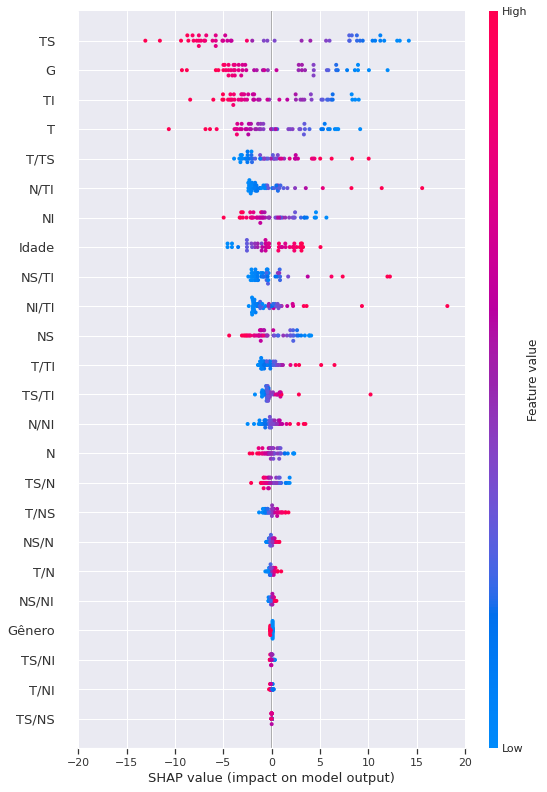

In [163]:
plt.xlim(xmin=-20,xmax=20) 
shap.summary_plot(shap_values_numerical, ft_numerical_train,max_display=30, feature_names=df.iloc[:,5:].columns.values)

## Average Importance

In [27]:
cross_tab = summary[(summary["k_fold"] == 5) & (summary["output_tab"] == 5)]

In [28]:
cross_tab

,model_id,k_fold,frac_val,val_best_acc,val_best_auc,val_best_sp,val_best_sn,val_avg_acc,val_avg_auc,val_avg_sp,val_avg_sn,train_best_acc,train_best_auc,train_best_sp,train_best_sn,train_avg_acc,train_avg_auc,train_avg_sp,train_avg_sn,host_name,optim,lr,scheduler,randaugop,epochs,double_img,output_tab,backbone,early_start,patient_el,timestamp,total_hours,average_cross_hours,torchvision_version,torch_version,history_added,shap_val,shap_oos,pred_val,pred_oos,batch_size,Usando OCT,Dual Image,group_backbone,regnet_vs_other,rank_max_auc,rank_avg_auc,oos_best_auc,avg_best_auc_oos,rank_max_auc_oct_double,rank_avg_auc_oct_double,rank_avg,std_val_auc,std_oos_auc,inference_time,avg_best_auc_val,max_sp_oos,max_sn_oos,idx_max_sp_val,idx_max_sn_val,idx_avg_sp_val,idx_avg_sn_val,avg_sp_oos,avg_sn_oos,std_sn_oos,std_sp_oos,idx_std_sn_val,idx_std_sp_val
864,86d27a1507a8431aada713f3f2b49a86,5.0,NaN,0.960526,0.943170,1.0,0.941176,0.791080,0.656461,0.978400,0.334521,0.963696,0.951526,1.0,0.921788,0.808277,0.663284,0.991119,0.335449,magneto,adam,0.0100,plateau,0,100.0,0.0,5.0,resnet,30.0,10.0,2022-12-20 16:50:38.557859,40:37:53.55,08:07:34.69,0.13.0+cu113,1.12.0+cu113,1.0,0,0,1,1,16,NaN,NaN,NaN,NaN,NaN,NaN,0.8484848484848485,0.633333,NaN,NaN,NaN,0.211740,0.163580,0.043,0.672788,1.000000,0.696970,1.000000,0.911765,0.993010,0.352566,1.000000,0.266667,0.327160,0.000000,0.432229,0.009928
865,1c6f3dc7ee844662b288be93b1c91235,5.0,NaN,0.947368,0.944562,1.0,0.954545,0.871546,0.817530,0.937668,0.697391,0.978583,0.972441,1.0,0.958580,0.916915,0.877610,0.967800,0.787419,magneto,adam,0.0005,plateau,0,100.0,0.0,5.0,regnet32y,30.0,10.0,2022-12-20 17:05:17.191984,40:54:24.74,08:10:52.93,0.13.0+cu113,1.12.0+cu113,1.0,1,1,1,1,16,NaN,NaN,NaN,NaN,NaN,NaN,0.8109452736318408,0.750249,NaN,NaN,NaN,0.034091,0.040288,0.043,0.896606,1.000000,0.666667,0.982301,0.954545,0.950853,0.842359,0.967164,0.533333,0.073231,0.025679,0.063598,0.026536
866,f13247f5d3414429857dbe30480d27b8,5.0,NaN,0.947368,0.928215,1.0,1.000000,0.871232,0.816939,0.943499,0.690378,0.980231,0.965335,1.0,0.932927,0.906883,0.858828,0.968249,0.749407,magneto,radam,0.0100,plateau,0,100.0,0.0,5.0,mobile,30.0,10.0,2022-12-20 18:25:09.029183,42:10:16.87,08:26:03.35,0.13.0+cu113,1.12.0+cu113,1.0,1,1,1,1,16,NaN,NaN,NaN,NaN,NaN,NaN,0.8713251922207146,0.775848,NaN,NaN,NaN,0.036641,0.068165,0.036,0.892337,1.000000,0.757576,1.000000,0.941176,0.945996,0.838677,0.988060,0.563636,0.132227,0.011169,0.066150,0.031780
867,ee824607e9f04221880088fcb2543986,5.0,NaN,0.973510,0.981308,1.0,1.000000,0.903793,0.863677,0.956564,0.770790,0.981848,0.972970,1.0,0.966480,0.937128,0.903996,0.979303,0.828688,magneto,ranger,0.0100,plateau,0,100.0,0.0,5.0,shuffle,30.0,10.0,2022-12-20 18:28:14.919040,42:12:45.79,08:26:33.13,0.13.0+cu113,1.12.0+cu113,1.0,1,1,1,1,16,NaN,NaN,NaN,NaN,NaN,NaN,0.8636363636363636,0.827318,NaN,NaN,NaN,0.029736,0.035347,0.046,0.935054,1.000000,0.727273,0.974576,1.000000,0.963071,0.907038,0.994030,0.660606,0.072727,0.011940,0.054609,0.008969
868,371f2592f8994c818e30a732c23aeaf6,5.0,NaN,0.921053,0.925972,1.0,0.970588,0.822139,0.756661,0.911556,0.601765,0.966997,0.955490,1.0,0.927374,0.886432,0.830614,0.957571,0.703657,magneto,radam,0.0010,plateau,0,100.0,0.0,5.0,shuffle,30.0,10.0,2022-12-20 18:35:37.071506,42:23:48.03,08:28:45.59,0.13.0+cu113,1.12.0+cu113,1.0,1,1,1,1,16,NaN,NaN,NaN,NaN,NaN,NaN,0.750565355042967,0.687246,NaN,NaN,NaN,0.078605,0.043177,0.041,0.825964,0.925373,0.575758,0.953271,0.970588,0.923825,0.728102,0.883582,0.490909,0.075210,0.023881,0.164027,0.026995
869,564ce1d63d4643a5a14005274a6715a2,5.0,NaN,0.914474,0.903041,1.0,0.911765,0.800148,0.722816,0.905366,0.540266,0.935644,0.917470,1.0,0.877095,0.858810,0.789403,0.947451,0.631355,magneto,ranger,0.0010,plateau,0,100.0,0.0,5.0,shuffle,30.0,10.0,2022-12-20 18:38:01.790833,42:26:53.13,08:29:22.60,0.13.0+cu113,1.12.0+cu113,1.0,1,1,1,1,16,NaN,NaN,NaN,NaN,NaN,NaN,0.7127996381727725,0.688874,NaN,NaN,NaN,0.070036,0.033600,0.041,0.795280,0.910448,0.606061,0.971429

In [29]:
summary[summary["model_id"] == "86d27a1507a8431aada713f3f2b49a86"]

,model_id,k_fold,frac_val,val_best_acc,val_best_auc,val_best_sp,val_best_sn,val_avg_acc,val_avg_auc,val_avg_sp,val_avg_sn,train_best_acc,train_best_auc,train_best_sp,train_best_sn,train_avg_acc,train_avg_auc,train_avg_sp,train_avg_sn,host_name,optim,lr,scheduler,randaugop,epochs,double_img,output_tab,backbone,early_start,patient_el,timestamp,total_hours,average_cross_hours,torchvision_version,torch_version,history_added,shap_val,shap_oos,pred_val,pred_oos,batch_size,Usando OCT,Dual Image,group_backbone,regnet_vs_other,rank_max_auc,rank_avg_auc,oos_best_auc,avg_best_auc_oos,rank_max_auc_oct_double,rank_avg_auc_oct_double,rank_avg,std_val_auc,std_oos_auc,inference_time,avg_best_auc_val,max_sp_oos,max_sn_oos,idx_max_sp_val,idx_max_sn_val,idx_avg_sp_val,idx_avg_sn_val,avg_sp_oos,avg_sn_oos,std_sn_oos,std_sp_oos,idx_std_sn_val,idx_std_sp_val
864,86d27a1507a8431aada713f3f2b49a86,5.0,NaN,0.960526,0.94317,1.0,0.941176,0.79108,0.656461,0.9784,0.334521,0.963696,0.951526,1.0,0.921788,0.808277,0.663284,0.991119,0.335449,magneto,adam,0.01,plateau,0,100.0,0.0,5.0,resnet,30.0,10.0,2022-12-20 16:50:38.557859,40:37:53.55,08:07:34.69,0.13.0+cu113,1.12.0+cu113,1.0,0,0,1,1,16,NaN,NaN,NaN,NaN,NaN,NaN,0.8484848484848485,0.633333,NaN,NaN,NaN,0.21174,0.16358,0.043,0.672788,1.0,0.69697,1.0,0.911765,0.99301,0.352566,1.0,0.266667,0.32716,0.0,0.432229,0.009928


In [30]:
def ranking_importance(model_id):
    print(model_id)
    row = summary[summary["model_id"] == model_id]
    model, train_loader, val_loader, input_size =  load_model_and_loaders(row, model_id)
    model = model.to(device)
    train = train_loader.dataset.glaucoma_data
    val = val_loader.dataset.glaucoma_data
    numerical_columns = train.select_dtypes(include=np.number).columns.tolist()
    numerical_columns.remove("label")
    ft_size = len(numerical_columns)
    transform_train ,transform_val,_ = init_transforms(input_size, 0)
    train_loader = init_dataloader(train, transform_train, None, 16, numerical_columns, False, False)
    val_loader = init_dataloader(val, transform_val, None, 16, numerical_columns, False, False)
    (
    photos1_train,
    photos2_train,
    ft_numerical_train,
    _,
    ) = get_samples_from_loader_balanced(train_loader, 50)
    (
    photos1_val,
    photos2_val,
    ft_numerical_val,
    _,
    ) = get_samples_from_loader(val_loader, len(val_loader.dataset))
    explainer = shap.DeepExplainer(
    model,
    [
        photos1_train.to(device),
        photos2_train.to(device),
        ft_numerical_train.to(device),
    ],
    )
    (
    shap_values_photo1,
    shap_values_photo2,
    shap_values_numerical,
    ) = explainer.shap_values([photos1_val, photos2_val, ft_numerical_val])
    df_importance = shapley_feature_ranking(shap_values_numerical)
    df_importance["rank"] = df_importance["importance"].rank(ascending=False,method="first").astype(int)
    df_importance.set_index("features",inplace=True)
    df_importance = df_importance.transpose()
    df_importance["model_id"] = model_id
    df_importance["dataset"] = "test"
    df_importance["metric"] = df_importance.index.values
    df_importance.reset_index(drop=True, inplace=True)
    df_importance["backbone"] = summary[summary["model_id"] == model_id]["backbone"].values[0]
    df_importance["model_id"] = model_id
    return df_importance

In [31]:
model_ids = cross_tab[cross_tab["backbone"] != "resnet"]["model_id"].values.tolist()

In [32]:
all_imp = []
for idx in model_ids:
    df_importance = ranking_importance(idx)
    all_imp.append(df_importance)
    torch.cuda.empty_cache() 

1c6f3dc7ee844662b288be93b1c91235
f13247f5d3414429857dbe30480d27b8


ee824607e9f04221880088fcb2543986
371f2592f8994c818e30a732c23aeaf6
564ce1d63d4643a5a14005274a6715a2
4b9591039ed648d5b4f444e7e8952f7b
2674d9c70bde4ceb8f078304f080b3ff
05155b3a1dac42d18b974104c98b9053
31cfeb035fb74bf68ae47eb0f769db55
a466a38bb66140d7b7a543a10dcf02cf
dcb701f24a184b05bbd08a4bc876b1d1


0e673f8c90a742c192aa9eaa5c89aec3
6c92c468c77746fab4010a6a0f6e21d4
65373da88d434c8eb46f6a281075dfb4
cc13a0cbc12f435d9438abf3eb8f71fe
b14f9dd34704488abbb3be82cb9aa124
5dc7ecb231344d38b5c4f83dc5e24f95
0f3f37260dbc4bd19b4d4124299726df
b674627d958947d79102841cdd7e2d90
86200d909a164bb58e2cfb12bf8cbb60


3c7d5f518e4b41ba856be357d074ddaf
c36921fe78f9415ba55b8dfe64a562f8
045f2241310845b1895949fad47a87df
76dc260776a24cfab89591e7c9b61571


In [33]:
importance_df = pd.concat(all_imp)

In [34]:
importance_df

features,TI,gender,TS,G,T/TS,age,NI,NS,N/TI,T/TI,N,TS/N,NS/N,T/N,TS/TI,NS/NI,NS/TI,TS/NS,NI/TI,N/NI,TS/NI,T/NS,T/NI,T,model_id,dataset,metric,backbone
0,0.002970,0.002824,0.002306,0.002253,0.002001,0.001350,0.001242,0.001141,0.000730,0.000623,0.000455,0.000391,0.000376,0.000333,0.000328,0.000319,0.000298,0.000295,0.000254,0.000228,0.000196,0.000140,0.000109,0.000089,1c6f3dc7ee844662b288be93b1c91235,test,importance,regnet32y
1,1.000000,2.000000,3.000000,4.000000,5.000000,6.000000,7.000000,8.000000,9.000000,10.000000,11.000000,12.000000,13.000000,14.000000,15.000000,16.000000,17.000000,18.000000,19.000000,20.000000,21.000000,22.000000,23.000000,24.000000,1c6f3dc7ee844662b288be93b1c91235,test,rank,regnet32y
0,0.834088,0.347457,0.854836,0.422379,0.517724,0.409081,0.436496,0.314032,0.325285,0.443073,0.247362,0.072898,0.008948,0.046590,0.007351,0.164432,0.193319,0.012412,0.187928,0.188953,0.036428,0.194504,0.108238,0.431404,f13247f5d3414429857dbe30480d27b8,test,importance,mobile
1,2.000000,9.000000,1.000000,7.000000,3.000000,8.000000,5.000000,11.000000,10.000000,4.000000,12.000000,19.000000,23.000000,20.000000,24.000000,17.000000,14.000000,22.000000,16.000000,15.000000,21.000000,13.000000,18.000000,6.000000,f13247f5d3414429857dbe30480d27b8,test,rank,mobile
0,1.246479,0.236835,2.909010,1.611159,1.725421,0.152286,0.231581,1.222407,0.707731,0.516087,0.294070,0.119836,0.489582,0.021897,0.087813,0.222307,0.864054,0.161275,0.718584,0.539623,0.279133,0.347241,0.060935,1.434305,ee824607e9f04221880088fcb2543986,test,importance,shuffle
1,5.000000,16.000000,1.000000,3.000000,2.000000,20.000000,17.000000,6.000000,9.000000,11.000000,14.000000,21.000000,12.000000,24.000000,22.000000,18.000000,7.000000,19.000000,8.000000,10.000000,15.000000,13.000000,23.000000,4.000000,ee824607e9f04221880088fcb2543986,test,rank,shuffle
0,0.154129,0.370423,0.262076,0.159415,0.215003,0.004026,0.058985,0.179202,0.054474,0.176383,0.050845,0.009089,0.096651,0.008137,0.009508,0.034411,0.107029,0.010385,0.056032,0.090392,0.018082,0.058375,0.102474,0.064974,371f2592f8994c818e30a732c23aeaf6,test,importance,shuffle
1,7.000000,1.000000,2.000000,6.000000,3.000000,24.000000,13.000000,4.000000,16.000000,5.000000,17.000000,22.000000,10.000000,23.000000,21.000000,18.000000,8.000000,20.000000,15.000000,11.000000,19.000000,14.000000,9.000000,12.000000,371f2592f8994c818e30a732c23aeaf6,test,rank,shuffle
0,0.033684,0.051867,0.044119,0.027062,0.041401,0.003339,0.013901,0.040078,0.003107,0.031673,0.008244,0.014017,0.019100,0.000797,0.000593,0.008715,0.015086,0.005343,0.010130,0.013789,0.002554,0.010846,0.017165,0.014500,564ce1d63d4643a5a14005274a6715a2,test,importance,shuffle
1,5.000000,1.000000,2.000000,7.000000,3.000000,20.000000,13.000000,4.000000,21.000000,6.000000,18.000000,12.000000,8.000000,23.000000,24.000000,17.000000,10.000000,19.000000,16.000000,14.000000,22.000000,15.000000,9.000000,11.000000,564ce1d63d4643a5a14005274a6715a2,test,rank,shuffle


In [136]:
imp_df = importance_df[importance_df["metric"] == "importance"]
imp_df = imp_df.groupby("backbone").mean()
imp_df

features,TI,gender,TS,G,T/TS,age,NI,NS,N/TI,T/TI,N,TS/N,NS/N,T/N,TS/TI,NS/NI,NS/TI,TS/NS,NI/TI,N/NI,TS/NI,T/NS,T/NI,T
backbone,,,,,,,,,,,,,,,,,,,,,,,,
efficient,2.215603,0.168082,6.088259,3.401059,2.569648,0.218158,0.634516,1.223176,1.721038,0.442442,0.409989,0.194498,0.124081,0.119861,0.132136,0.425818,1.320081,0.596258,1.215297,0.600407,0.305437,0.472431,0.574721,3.221123
inception,0.886252,0.115497,1.951322,0.706525,0.690766,0.532145,0.231196,0.708910,0.422957,0.196628,0.363614,0.083630,0.025307,0.073652,0.085875,0.068507,0.545185,0.027716,0.338022,0.342145,0.101062,0.163126,0.075186,0.786684
mobile,0.834088,0.347457,0.854836,0.422379,0.517724,0.409081,0.436496,0.314032,0.325285,0.443073,0.247362,0.072898,0.008948,0.046590,0.007351,0.164432,0.193319,0.012412,0.187928,0.188953,0.036428,0.194504,0.108238,0.431404
regnet16x,1.444052,0.202890,2.524474,1.553816,1.069169,0.616252,0.801629,0.829277,0.869129,0.564909,0.352747,0.273342,0.106234,0.101481,0.195563,0.114782,0.631947,0.154591,0.608926,0.416869,0.062997,0.244446,0.078889,1.144444
regnet16y,1.458609,0.323520,2.635947,1.553003,1.179408,0.381911,0.498711,0.729366,0.955924,0.804645,0.307806,0.228354,0.170515,0.037998,0.105005,0.216603,0.553075,0.243907,0.507581,0.372544,0.240223,0.249260,0.150963,1.116220
regnet32x,1.124364,0.179894,2.462983,1.570332,1.271546,0.255394,0.460816,0.969214,0.938159,0.278696,0.200534,0.240939,0.240509,0.070978,0.125905,0.218479,0.762884,0.242324,0.753508,0.298109,0.143013,0.199626,0.173595,1.202769
regnet32y,0.953286,0.029064,1.386047,0.614689,0.514109,0.109237,0.330572,0.369194,0.376305,0.315994,0.326157,0.131295,0.076583,0.015152,0.050863,0.066170,0.336877,0.034900,0.300011,0.135073,0.033975,0.046552,0.106340,0.654827
regnetx,1.804980,0.086609,3.504753,1.964377,1.608061,0.341529,0.676518,1.003053,0.980739,0.389649,0.196029,0.101991,0.213864,0.097295,0.048432,0.332653,0.940720,0.295714,0.968423,0.478779,0.150106,0.337792,0.368830,2.007018
shuffle,0.892457,0.298730,1.967332,1.091760,1.100626,0.179727,0.172844,0.784813,0.503761,0.450090,0.164498,0.068467,0.287795,0.020334,0.069709,0.151534,0.567828,0.054979,0.445149,0.382050,0.161754,0.213826,0.066518,0.846919


<AxesSubplot:xlabel='features', ylabel='backbone'>

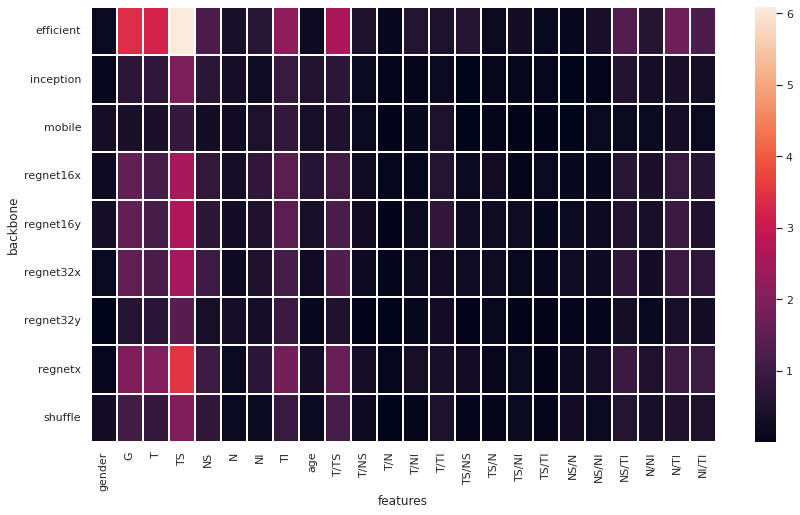

In [137]:
fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(imp_df[numerical_columns], linewidths=0.2)

Text(111.5, 0.5, 'Caracaterísticas')

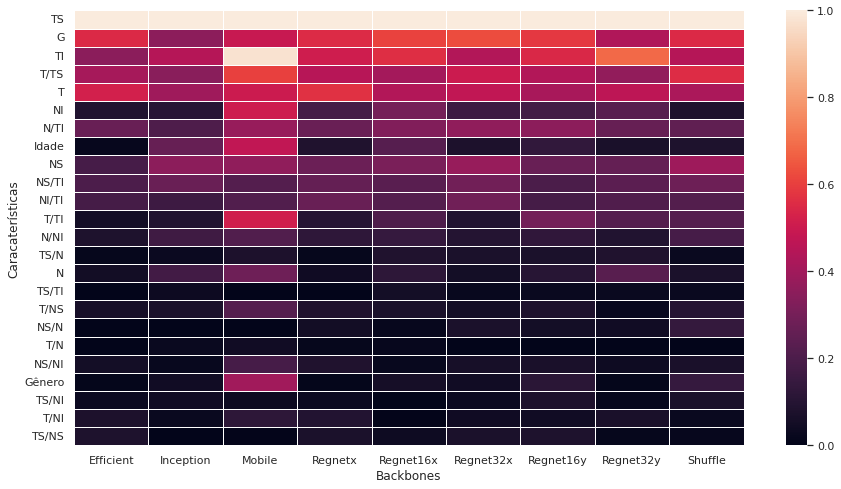

In [139]:
imp_shap = ["TS","G","TI","T/TS","T","NI","N/TI","Idade","NS","NS/TI","NI/TI","T/TI","N/NI","TS/N","N","TS/TI","T/NS","NS/N","T/N","NS/NI","Gênero","TS/NI","T/NI","TS/NS"]
imp_df.rename(columns={"age": "Idade","gender": "Gênero"}, inplace=True)
min_max_imp_df = imp_df.apply(lambda x: ((x - x.min()) / (x.max() - x.min())), axis=1).T
min_max_imp_df = min_max_imp_df.reindex(imp_shap)
min_max_imp_df = min_max_imp_df[["efficient","inception","mobile","regnetx","regnet16x","regnet32x","regnet16y","regnet32y","shuffle"]]
min_max_imp_df.columns = ["Efficient","Inception","Mobile","Regnetx","Regnet16x","Regnet32x","Regnet16y","Regnet32y","Shuffle"]
fig, ax = plt.subplots(figsize=(15, 8))
ax = sns.heatmap(min_max_imp_df, linewidths=0.5)
ax.set_xlabel("Backbones",fontsize=12)
ax.set_ylabel("Caracaterísticas",fontsize=12)